In [68]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os


load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [69]:
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest"
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-latest', client=<google.genai.client.Client object at 0x000001DB52F0D330>, default_metadata=(), model_kwargs={})

In [70]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal['insta', 'twitter', 'linkedin'] = Field(..., description="Can be either insta, twitter or linkedin")
    topic: str = Field(..., description="The topic for which the post needs to be generated")

In [71]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [72]:
llm_with_schema.invoke("I want to generate a post for twitter about AI")

llm_schema(category='twitter', topic='AI')

In [73]:
from typing import TypedDict,List

class graph_schema(TypedDict):

    input: str
    topic:str
    post: str
    category: str

In [74]:
def decider_node(state: graph_schema) -> graph_schema:
    user_input = state["input"]

    result = llm_with_schema.invoke(user_input)

    category = result.category   # string
    topic = result.topic  

    state["category"] = category
    state["topic"] = topic

    return state

def create_post_insta(state: graph_schema) -> graph_schema:


    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate an Instagram post
    post = llm.invoke(
        f"Write an Instagram post about {topic}. Keep the tone casual and engaging."
    ).content

    # Update the state with the generated post
    state['post'] = post

    return {"post": post}

def create_post_twitter(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state['topic']

    post = llm.invoke(
        f"Write an Twitter post about {topic}. Keep the tone quick."
    ).content

    # Update the state with the generated post
    state['post'] = post

    return {"post": post}

def create_post_linkedin(state: graph_schema) -> graph_schema:

    # Extract the topic from the state
    topic = state['topic']

    post = llm.invoke(
        f"Write an LinkedIn post about {topic}. Keep the tone professional."
    ).content

    # Update the state with the generated post
    state['post'] = post

    return {"post": post}

In [75]:
def condition(state: graph_schema) -> str:
    category = state['category']

    if category == 'insta':
        return 'create_insta_post'
    elif category == 'twitter':
        return 'create_twitter_post'
    elif category == 'linkedin':
        return 'create_linkedin_post'
    else:
        raise ValueError("Invalid category")

In [76]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("create_insta_post", create_post_insta)
graph.add_node("create_twitter_post", create_post_twitter)
graph.add_node("create_linkedin_post", create_post_linkedin)

graph.add_edge(START, "decider")
graph.add_conditional_edges("decider", condition,{
    "create_insta_post":"create_insta_post",
    "create_twitter_post":"create_twitter_post",
    "create_linkedin_post": "create_linkedin_post"
})
graph.add_edge("create_insta_post", END)
graph.add_edge("create_twitter_post", END)
graph.add_edge("create_linkedin_post", END)

route_graph = graph.compile()


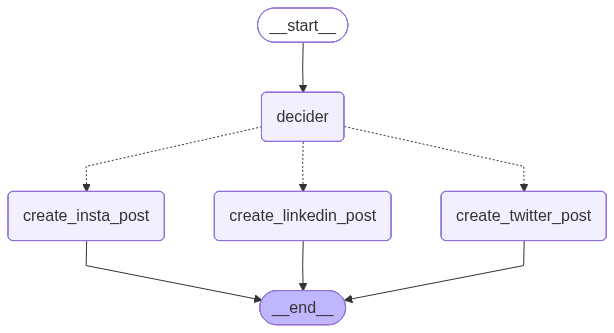

In [77]:
#Step 4 Compile the graph
from IPython.display import Image, display

Image(route_graph.get_graph().draw_mermaid_png())

In [78]:
route_graph.invoke(
    {
        "input": "I want to generate a post for twitter about AI",
        "topic":"",
        "category":"",
        "post": ""
                
    }
)

{'input': 'I want to generate a post for twitter about AI',
 'topic': 'AI',
 'post': [{'type': 'text',
   'text': 'AI is moving at light speed. ⚡️\n\nBlink and there’s a new tool changing the game. You’re either using it to level up or getting left behind. \n\nWhat’s your #1 AI tool right now? 👇 #AI #TechTrends',
   'extras': {'signature': 'EuUKCuIKAb4+9vsuavSpCkJkWFxoAoIDTVXzEGbFYsMQvsExPUDdsP7LRNgWyYwWijZoU3K6BroQg3U0xsm2XuDDxAZ0hdH3ZRnpa1fR4ur5g12xUVcumAljTBTbQd+epJHJVeq4tSNvmiPt6IlDp7Or/u1HBl054N3iLIm3TlniGIWZmPi6q550gVnZdqf/X5QbdJpH81Zi4jLz0cipwwZrHSMfqLBxkj2r21ggj18tYMU1S5pkhACvvXuxnIulFTFCNZxab7Efl1Q+XqbrMp7DHjfhW8TgR+W8wflQTfxjKohRXJ1gVNaoJO1vKUJnagJcyiGJUDS/bJEypy4fkBZ4EjGeFiykfF4H39V4kCln3V8qVNKwUQRfZ28oleRIvQTk/53lsuFXgF2RsszEAqyVZYo2yYLMgvfVYbmxY2x0565ThODvFLRwPRn5LNfhLc6GP+Y+SxWQhFj28V2F04J38FctbeqQzmC/LZFQQTt0rvBbzCiZlNvSC4pnwrswvwsNCNPDYZUxS9Gddm2KU85yQnbgk6LWQFf6R4/98poc6vMss9XIXvaeVkzoIHuEFZwV8XXB/q7CESbLcL17YCQYEWsMNKYwK3Dl7UeVG5POl0Jjf4RFgjD64ZD/eI8lNudZibsVPcTkCortC